In [ ]:
import pandas as pd

df = pd.read_parquet('Player-Games with Injuries.parquet')
df['Position'] = df['Position'].map({
    'PG': 1,
    'SG': 2,
    'SF': 3,
    'PF': 4,
    'C': 5,
})

In [ ]:
print(df['playerteamName'].unique())

['Suns' 'Clippers' 'Cavaliers' 'Celtics' 'Trail Blazers' 'Heat'
 'Mavericks' 'Knicks' 'Spurs' 'Bobcats' 'Lakers' 'Hawks' 'Bucks' 'Bulls'
 'Nets' 'Timberwolves' '76ers' 'Rockets' 'Thunder' 'Hornets' 'Raptors'
 'Warriors' 'Pistons' 'Nuggets' 'Magic' 'Wizards' 'Grizzlies' 'Kings'
 'Pacers' 'Jazz' 'Pelicans']


In [ ]:
from utils import test_model

ROC-AUC: 0.5729551759927131
PR-AUC: 0.20360351740903831


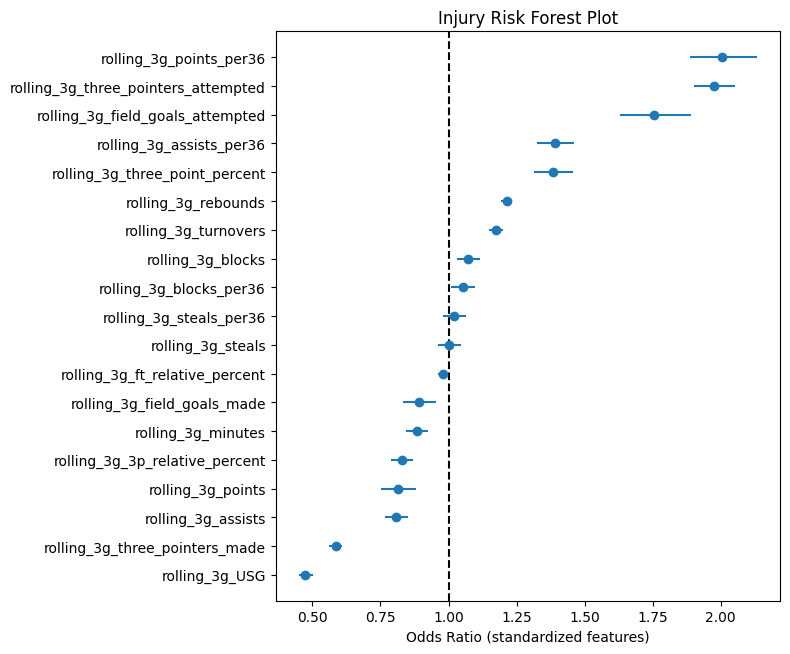

ROC-AUC: 0.5747625412286194
PR-AUC: 0.20378686140113916


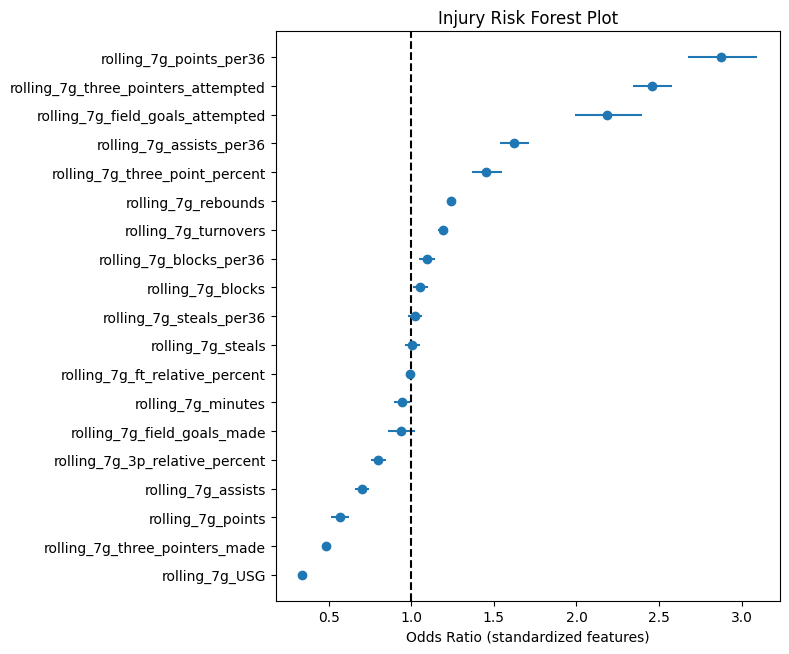

rolling 3 0.5729551759927131 0.20360351740903831
rolling 7 0.5747625412286194 0.20378686140113916


In [ ]:
df_model_rolling3 = df[[c for c in df.columns if "rolling_3g" in c] + ['injury_within_14d', 'gameDateTimeEst_player']]
df_model_rolling3 = df_model_rolling3.dropna()

df_model_rolling7 = df[[c for c in df.columns if "rolling_7g" in c] + ['injury_within_14d', 'gameDateTimeEst_player']]
df_model_rolling7 = df_model_rolling7.dropna()

or_df_3, auc_3, ap_3 = test_model(df_model_rolling3)
or_df_7, auc_7, ap_7 = test_model(df_model_rolling7)

print('rolling 3', auc_3, ap_3)
print('rolling 7', auc_7, ap_7)

In [ ]:
def clean_name(x):
    return x.replace("rolling_3g_", "").replace("rolling_7g_", "")

or_df_3_mod = or_df_3.copy()
or_df_7_mod = or_df_7.copy()

or_df_3_mod["feature"] = or_df_3_mod["feature"].apply(clean_name)
or_df_7_mod["feature"] = or_df_7_mod["feature"].apply(clean_name)

or_df_3_mod = or_df_3_mod.rename(columns={
    "OR": "OR_3",
    "lower": "lower_3",
    "upper": "upper_3"
})

or_df_7_mod = or_df_7_mod.rename(columns={
    "OR": "OR_7",
    "lower": "lower_7",
    "upper": "upper_7"
})

combined_or = or_df_3_mod.merge(or_df_7_mod, on="feature", how="inner")
combined_or["OR_ratio_3_vs_7"] = combined_or["OR_3"] / combined_or["OR_7"]

combined_or = combined_or.sort_values("OR_ratio_3_vs_7")
combined_or

,feature,OR_3,lower_3,upper_3,OR_7,lower_7,upper_7,OR_ratio_3_vs_7
18,points_per36,2.005556,1.885458,2.133303,2.877450,2.676963,3.092952,0.696991
16,field_goals_attempted,1.755260,1.628777,1.891564,2.183462,1.990430,2.395214,0.803888
17,three_pointers_attempted,1.975589,1.902813,2.051148,2.455520,2.339566,2.577222,0.804550
15,assists_per36,1.391773,1.326752,1.459980,1.622621,1.536372,1.713711,0.857731
5,minutes,0.882584,0.843320,0.923676,0.943190,0.894595,0.994424,0.935744
6,field_goals_made,0.890497,0.831167,0.954062,0.938052,0.861724,1.021142,0.949304
14,three_point_percent,1.384660,1.314314,1.458771,1.453371,1.365827,1.546527,0.952723
10,blocks_per36,1.053126,1.010048,1.098041,1.095152,1.046357,1.146223,0.961625
13,rebounds,1.213858,1.194082,1.233962,1.241971,1.219792,1.264552,0.977365
12,turnovers,1.174569,1.149890,1.199777,1.192033,1.162583,1.222230,0.985349


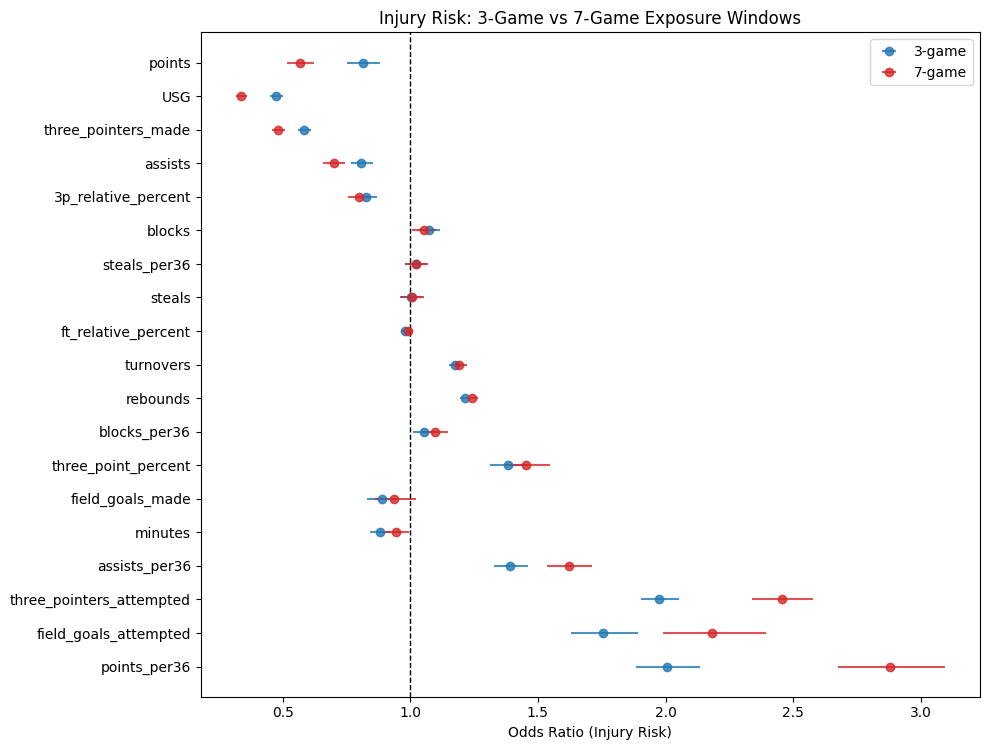

In [ ]:
df3 = combined_or[["feature", "OR_3", "lower_3", "upper_3"]].copy()
df3.columns = ["feature", "OR", "lower", "upper"]
df3["model"] = "3-game"

df7 = combined_or[["feature", "OR_7", "lower_7", "upper_7"]].copy()
df7.columns = ["feature", "OR", "lower", "upper"]
df7["model"] = "7-game"

plot_df = pd.concat([df3, df7], ignore_index=True)

feature_order = (
    combined_or.sort_values("OR_7")["feature"].tolist()
)
plot_df["feature"] = pd.Categorical(plot_df["feature"], categories=feature_order, ordered=True)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, max(6, len(feature_order) * 0.4)))

colors = {"3-game": "tab:blue", "7-game": "tab:red"}

for model in ["3-game", "7-game"]:
    sub = plot_df[plot_df["model"] == model]

    ax.errorbar(
        sub["OR"],
        sub["feature"],
        xerr=[
            sub["OR"] - sub["lower"],
            sub["upper"] - sub["OR"]
        ],
        fmt="o",
        label=model,
        alpha=0.8,
        color=colors[model]
    )

ax.axvline(1, linestyle="--", color="black", linewidth=1)

ax.set_xlabel("Odds Ratio (Injury Risk)")
ax.set_title("Injury Risk: 3-Game vs 7-Game Exposure Windows")
ax.legend()

plt.tight_layout()
plt.show()

ROC-AUC: 0.5830177865587813
PR-AUC: 0.21009866255900084


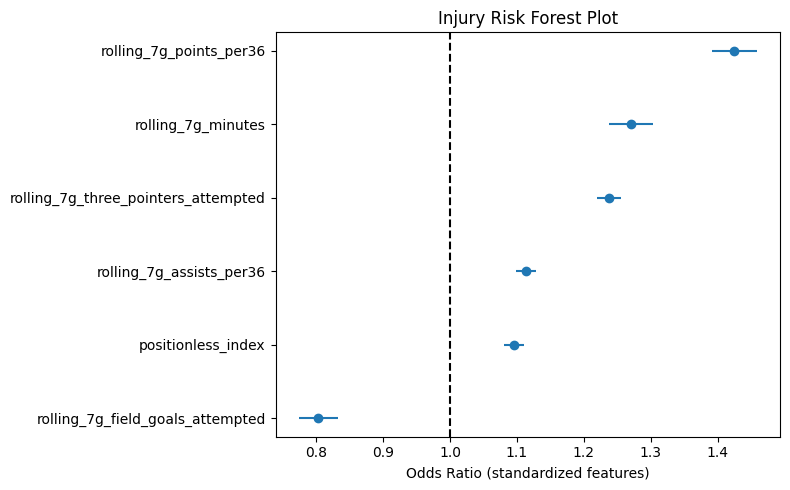

In [ ]:
features = ['rolling_7g_points_per36', 'rolling_7g_field_goals_attempted',
            'rolling_7g_three_pointers_attempted', 'rolling_7g_assists_per36',
            'rolling_7g_minutes', 'positionless_index']
df_main_model = df[features + ['injury_within_14d', 'gameDateTimeEst_player']]
df_main_model = df_main_model.dropna()

odds, auc, ap = test_model(df_main_model)

In [ ]:
print(odds, auc, ap)

                               feature        OR     lower     upper
2     rolling_7g_field_goals_attempted  0.802504  0.773536  0.832557
6                   positionless_index  1.095553  1.080518  1.110797
4             rolling_7g_assists_per36  1.113760  1.099362  1.128347
3  rolling_7g_three_pointers_attempted  1.237101  1.219241  1.255222
5                   rolling_7g_minutes  1.270385  1.238108  1.303504
1              rolling_7g_points_per36  1.424687  1.391164  1.459018 0.5830177865587813 0.21009866255900084
